# DSBDA Lab Assignment No. 8
## Data Visualisation I — Titanic Dataset
**Department of Computer Engineering**

**Objective:** Perform data visualization operations using Python on the Titanic dataset using the Seaborn library to find patterns in data and analyze ticket fare distribution.

---
## 1. Imports and Dataset Loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (8, 5)

---
## 2. Know Your Data

In [5]:
# Load the built-in Titanic dataset
dataset = sns.load_dataset('titanic')

print(f"Shape: {dataset.shape}")
print(f"Rows: {dataset.shape[0]}, Columns: {dataset.shape[1]}")
dataset.head()

Shape: (891, 15)
Rows: 891, Columns: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [15]:
# Dataset info
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [16]:
# Basic statistics
dataset.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


---
## 3. Finding Patterns in Data

### A. Distribution Plots
Used to visualize distribution of continuous/numeric data — helps understand mean, median, range, variance, deviation.

#### a. Dist Plot (Histogram + KDE)
- Univariate analysis
- Shows histogram of a selected continuous variable with optional KDE overlay

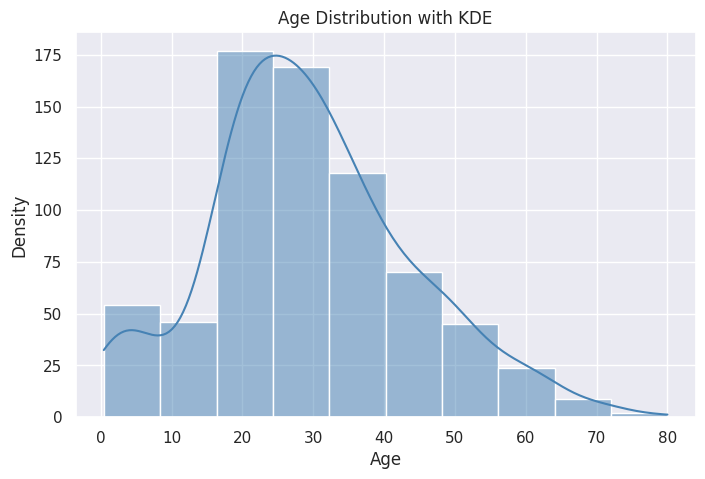

In [17]:
# Distplot with KDE (using histplot as distplot is deprecated in modern seaborn)
plt.figure(figsize=(8, 5))
sns.histplot(dataset['age'].dropna(), bins=10, kde=True, color='steelblue')
plt.title('Age Distribution with KDE')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

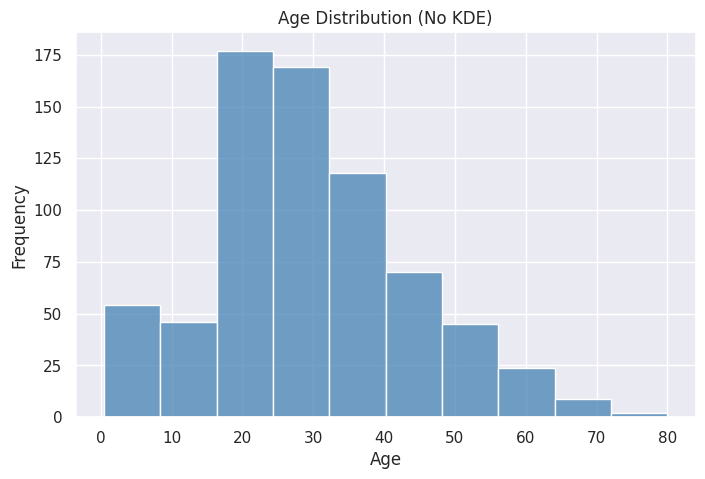

Observation: ~50 passengers are aged 0–10, highest count is in the 20–30 age bracket.


In [18]:
# Distplot without KDE
plt.figure(figsize=(8, 5))
sns.histplot(dataset['age'].dropna(), bins=10, kde=False, color='steelblue')
plt.title('Age Distribution (No KDE)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

print("Observation: ~50 passengers are aged 0–10, highest count is in the 20–30 age bracket.")

#### b. Joint Plot
- Bivariate analysis: combination of dist plots for two variables
- Shows scatter/hexbin plot + marginal distributions

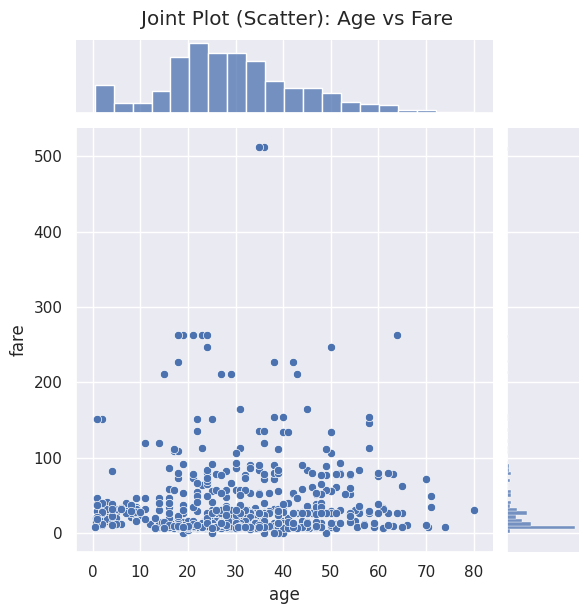

In [19]:
# Joint Plot — Scatter kind
g = sns.jointplot(x=dataset['age'], y=dataset['fare'], kind='scatter', height=6)
g.figure.suptitle('Joint Plot (Scatter): Age vs Fare', y=1.02)
plt.show()

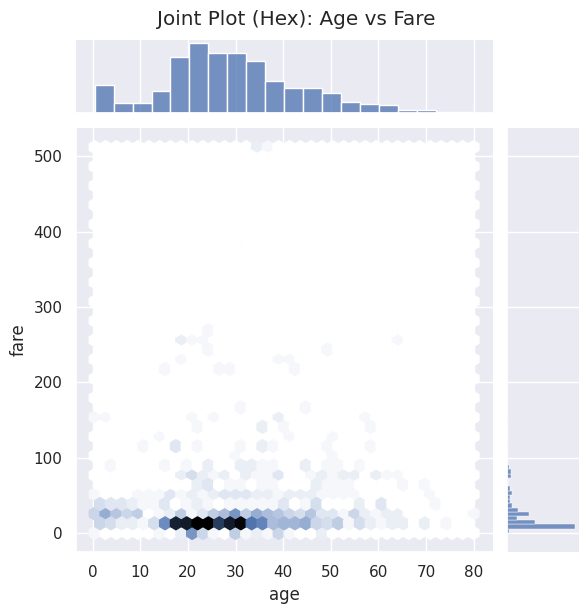

Observation: Most passengers are aged 20–30 and paid fares between 10–50.
No strong linear correlation between age and fare.


In [20]:
# Joint Plot — Hex kind
g = sns.jointplot(x=dataset['age'], y=dataset['fare'], kind='hex', height=6)
g.figure.suptitle('Joint Plot (Hex): Age vs Fare', y=1.02)
plt.show()

print("Observation: Most passengers are aged 20–30 and paid fares between 10–50.")
print("No strong linear correlation between age and fare.")

#### c. Rug Plot
- Draws small bars along the x-axis for each data point
- Useful to visualize density of individual observations

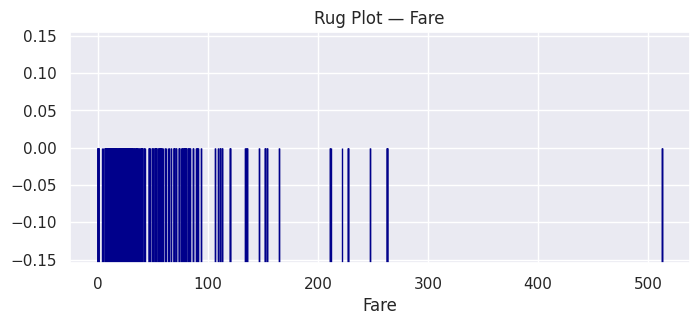

Observation: Most fare values are concentrated between 0 and 100.


In [21]:
plt.figure(figsize=(8, 3))
sns.rugplot(data=dataset, x='fare', height=0.5, color='darkblue')
plt.title('Rug Plot — Fare')
plt.xlabel('Fare')
plt.show()

print("Observation: Most fare values are concentrated between 0 and 100.")

---
### B. Categorical Plots
Used to plot categorical data against numeric columns — good for group comparisons.

#### a. Bar Plot
- Displays the mean (or any aggregate) of a numeric column for each category

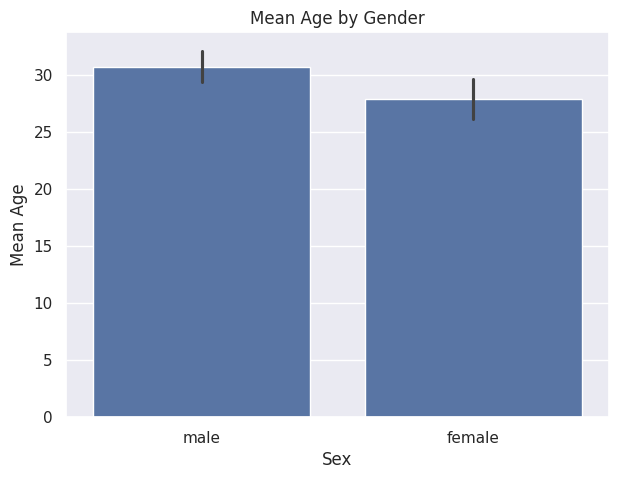

Observation: Average age of male passengers ~30, female passengers ~28.


In [22]:
# Bar plot: Mean age by sex
plt.figure(figsize=(7, 5))
sns.barplot(x='sex', y='age', data=dataset)
plt.title('Mean Age by Gender')
plt.xlabel('Sex')
plt.ylabel('Mean Age')
plt.show()

print("Observation: Average age of male passengers ~30, female passengers ~28.")

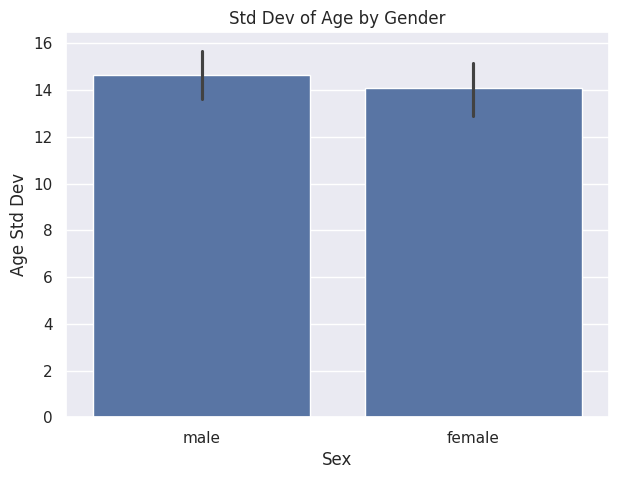

In [23]:
# Bar plot: Standard deviation of age by sex (custom estimator)
plt.figure(figsize=(7, 5))
sns.barplot(x='sex', y='age', data=dataset, estimator=np.std)
plt.title('Std Dev of Age by Gender')
plt.xlabel('Sex')
plt.ylabel('Age Std Dev')
plt.show()

#### b. Count Plot
- Counts occurrences of each category value

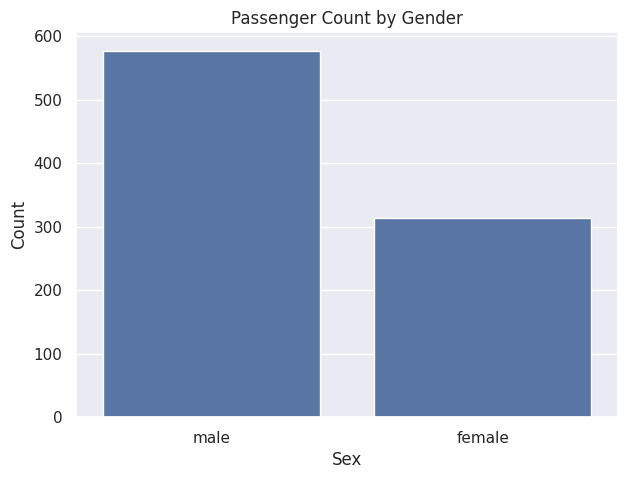

Male count  : 577
Female count: 314


In [24]:
plt.figure(figsize=(7, 5))
sns.countplot(x='sex', data=dataset)
plt.title('Passenger Count by Gender')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

print(f"Male count  : {dataset['sex'].value_counts()['male']}")
print(f"Female count: {dataset['sex'].value_counts()['female']}")

#### c. Box Plot
- Displays distribution via quartiles: Q1, median, Q3, whiskers, and outliers

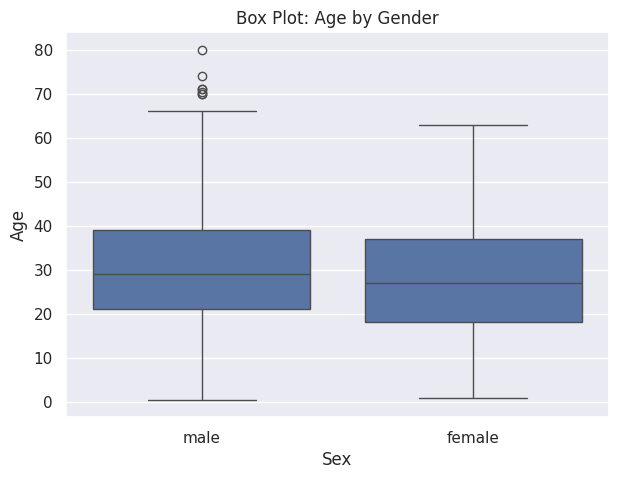

Box Plot Interpretation (Female):
  Q1 (25%): ~1–20 years
  Q2 (50%): ~20–28 years (median)
  Q3 (75%): ~28–38 years
  Q4 (100%): ~38–64 years
  Dots above whiskers = outliers


In [25]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='sex', y='age', data=dataset)
plt.title('Box Plot: Age by Gender')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.show()

print("Box Plot Interpretation (Female):")
print("  Q1 (25%): ~1–20 years")
print("  Q2 (50%): ~20–28 years (median)")
print("  Q3 (75%): ~28–38 years")
print("  Q4 (100%): ~38–64 years")
print("  Dots above whiskers = outliers")

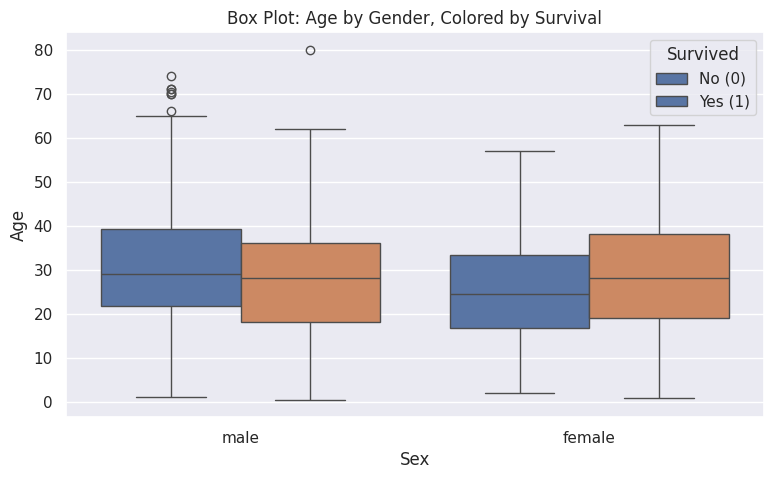

Observation: Among males, younger passengers had a higher survival rate.
Female survival age variation is much wider for non-survivors.


In [26]:
# Box plot with hue (survival overlay)
plt.figure(figsize=(9, 5))
sns.boxplot(x='sex', y='age', data=dataset, hue='survived')
plt.title('Box Plot: Age by Gender, Colored by Survival')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

print("Observation: Among males, younger passengers had a higher survival rate.")
print("Female survival age variation is much wider for non-survivors.")

#### d. Violin Plot
- Combines box plot with KDE — shows full distribution shape, not just quartiles

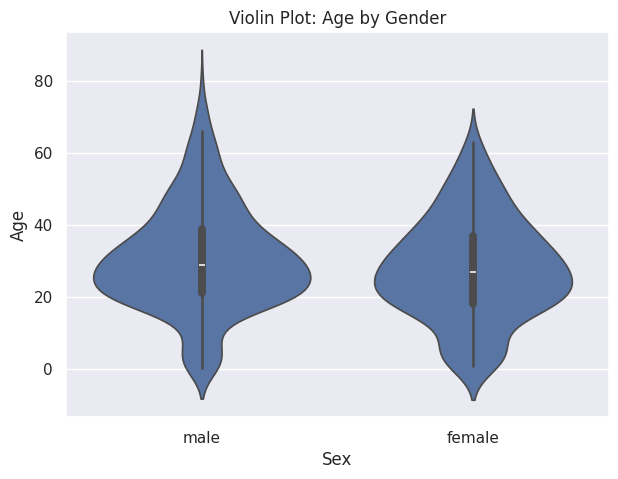

Observation: The violin is thicker at 20–40 for males — higher passenger density in that range.


In [27]:
plt.figure(figsize=(7, 5))
sns.violinplot(x='sex', y='age', data=dataset)
plt.title('Violin Plot: Age by Gender')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.show()

print("Observation: The violin is thicker at 20–40 for males — higher passenger density in that range.")

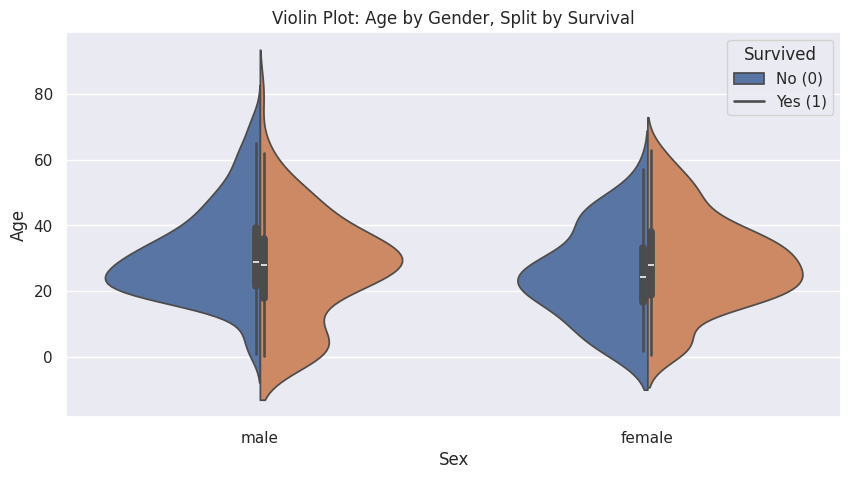

Observation: Young male survivors (bottom of violin) are more than young male non-survivors.


In [28]:
# Violin plot with hue
plt.figure(figsize=(10, 5))
sns.violinplot(x='sex', y='age', data=dataset, hue='survived', split=True)
plt.title('Violin Plot: Age by Gender, Split by Survival')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

print("Observation: Young male survivors (bottom of violin) are more than young male non-survivors.")

---
### C. Advanced Plots

#### a. Strip Plot
- Scatter plot where one axis is categorical
- `jitter=True` adds horizontal noise for better readability

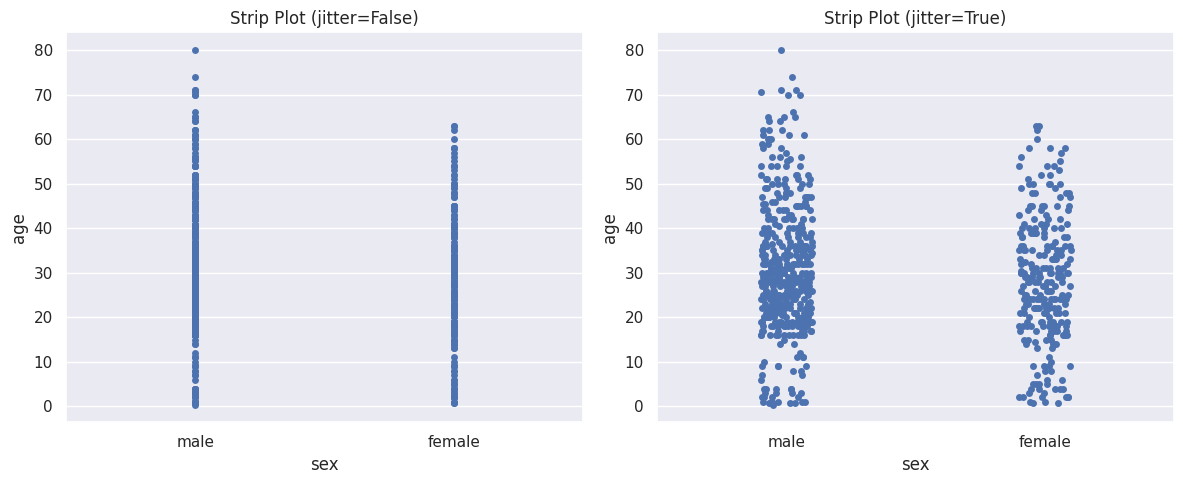

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.stripplot(x='sex', y='age', data=dataset, jitter=False, ax=axes[0])
axes[0].set_title('Strip Plot (jitter=False)')

sns.stripplot(x='sex', y='age', data=dataset, jitter=True, ax=axes[1])
axes[1].set_title('Strip Plot (jitter=True)')

plt.tight_layout()
plt.show()

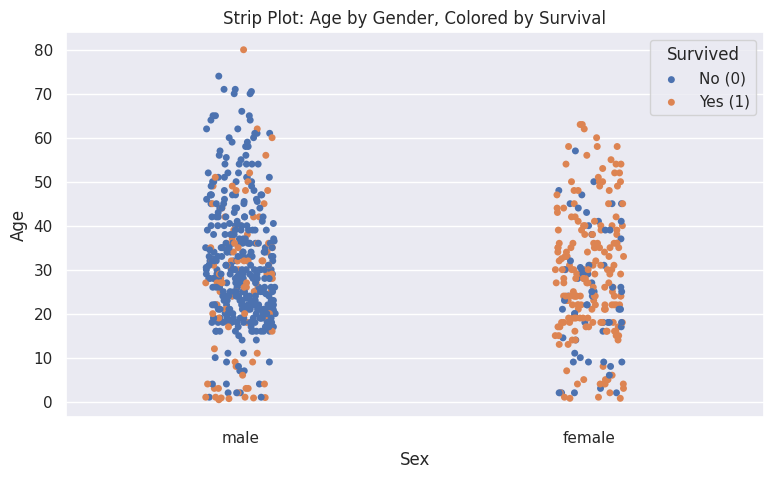

In [30]:
# Strip plot with hue
plt.figure(figsize=(9, 5))
sns.stripplot(x='sex', y='age', data=dataset, jitter=True, hue='survived')
plt.title('Strip Plot: Age by Gender, Colored by Survival')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

#### b. Swarm Plot
- Combination of strip + violin: non-overlapping points arranged to show density

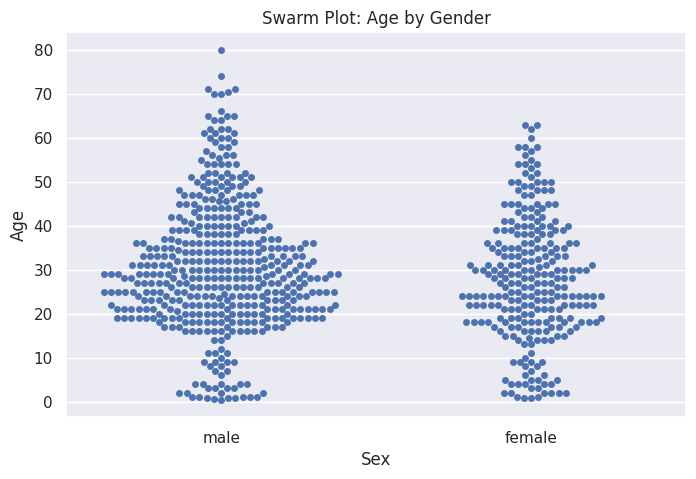

In [31]:
plt.figure(figsize=(8, 5))
sns.swarmplot(x='sex', y='age', data=dataset)
plt.title('Swarm Plot: Age by Gender')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.show()

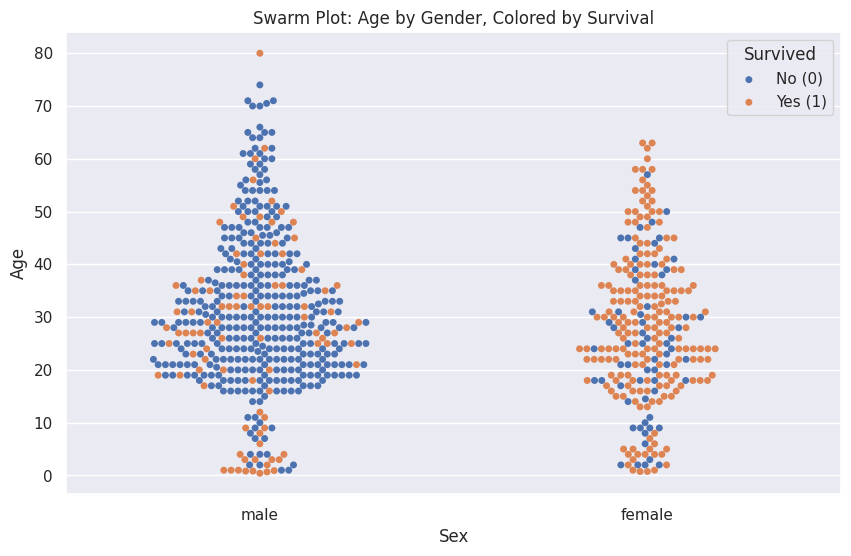

Observations:
  - Male plot: more blue (non-surviving) than orange (surviving) → lower male survival ratio
  - Female plot: more orange than blue → higher female survival ratio
  - Male children (<10): more survivors than non-survivors


In [32]:
# Swarm plot with hue
plt.figure(figsize=(10, 6))
sns.swarmplot(x='sex', y='age', data=dataset, hue='survived')
plt.title('Swarm Plot: Age by Gender, Colored by Survival')
plt.xlabel('Sex')
plt.ylabel('Age')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

print("Observations:")
print("  - Male plot: more blue (non-surviving) than orange (surviving) → lower male survival ratio")
print("  - Female plot: more orange than blue → higher female survival ratio")
print("  - Male children (<10): more survivors than non-survivors")

---
### D. Matrix Plots

#### a. Heat Map
- Shows correlation between all numeric columns as a color-coded matrix

In [33]:
# Compute correlation matrix (numeric columns only)
corr = dataset.select_dtypes(include='number').corr()
print("Correlation Matrix:")
corr

Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


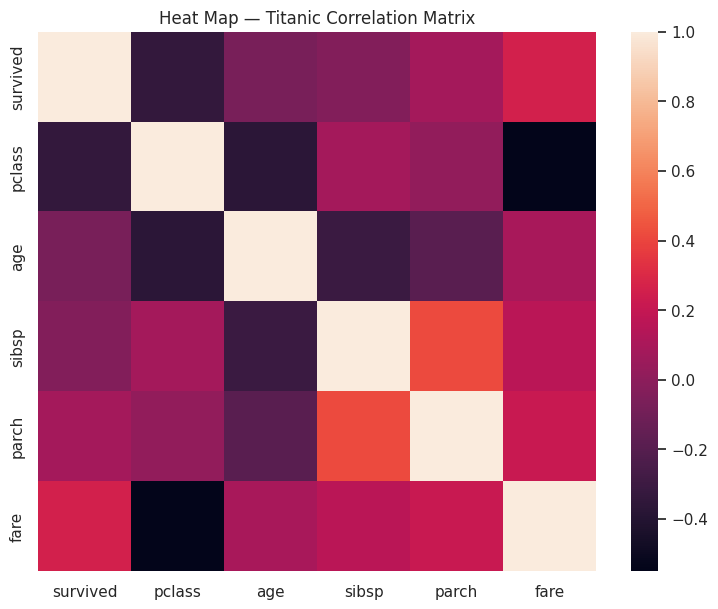

In [34]:
# Heat map without annotations
plt.figure(figsize=(9, 7))
sns.heatmap(corr)
plt.title('Heat Map — Titanic Correlation Matrix')
plt.show()

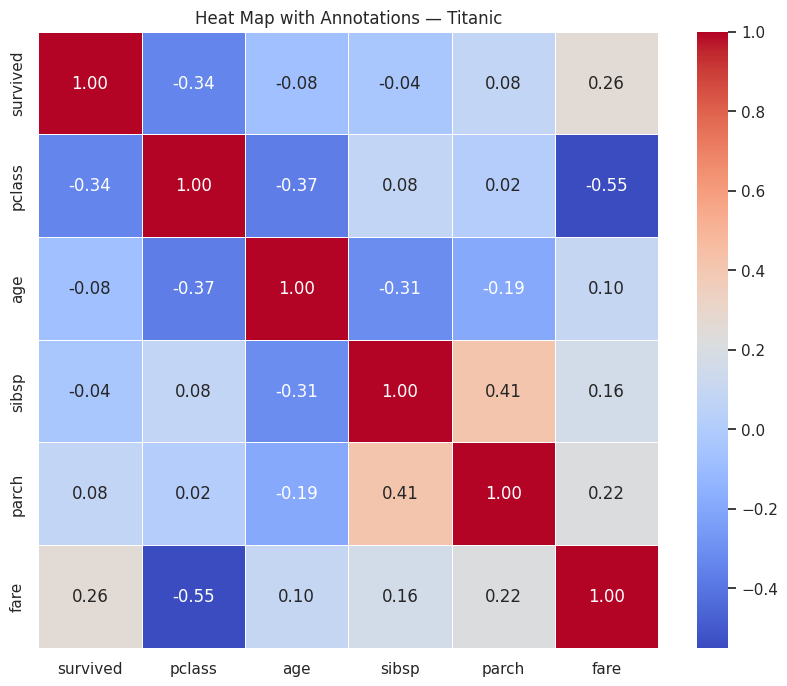

Observation: 'fare' has moderate positive correlation (~0.26) with survival.
'pclass' has a strong negative correlation (~-0.55) with fare — higher class = lower fare.


In [35]:
# Heat map with correlation values annotated
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heat Map with Annotations — Titanic')
plt.show()

print("Observation: 'fare' has moderate positive correlation (~0.26) with survival.")
print("'pclass' has a strong negative correlation (~-0.55) with fare — higher class = lower fare.")

#### b. Cluster Map
- Uses Hierarchical Clustering to rearrange rows and columns of the correlation matrix

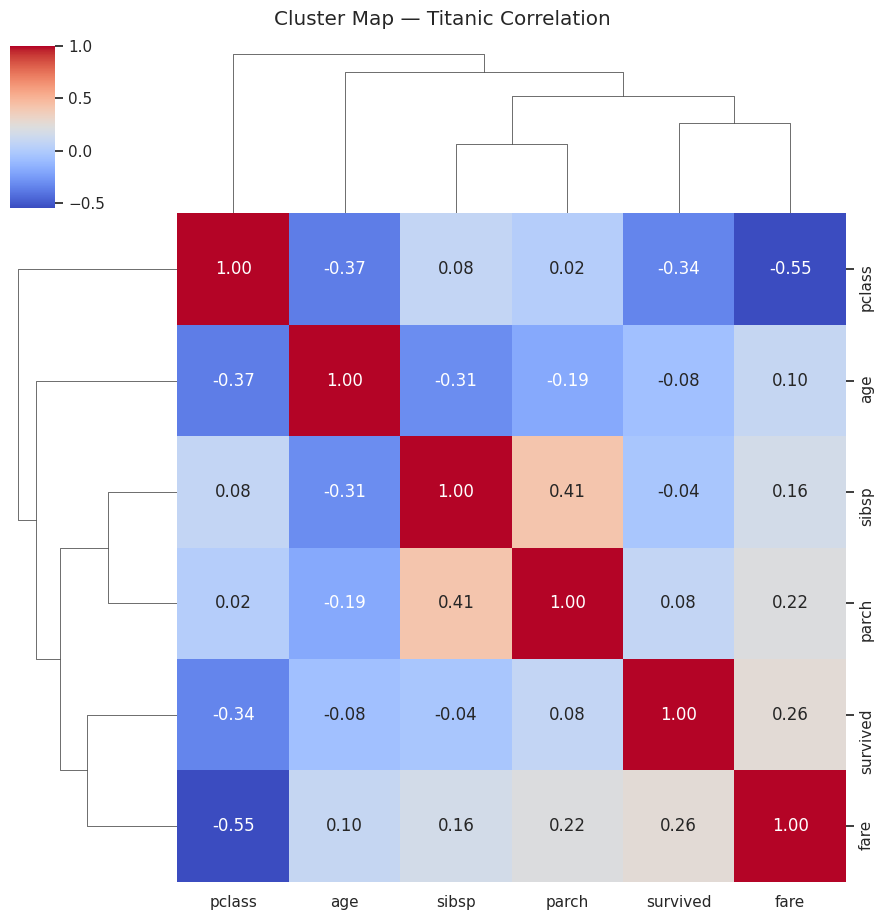

In [36]:
sns.clustermap(corr, annot=True, fmt='.2f', cmap='coolwarm', figsize=(9, 9))
plt.suptitle('Cluster Map — Titanic Correlation', y=1.02)
plt.show()

---
## 4. Ticket Fare Distribution — Histogram (Main Task)

**Task:** Check how the price of the ticket (`fare`) for each passenger is distributed by plotting a histogram.

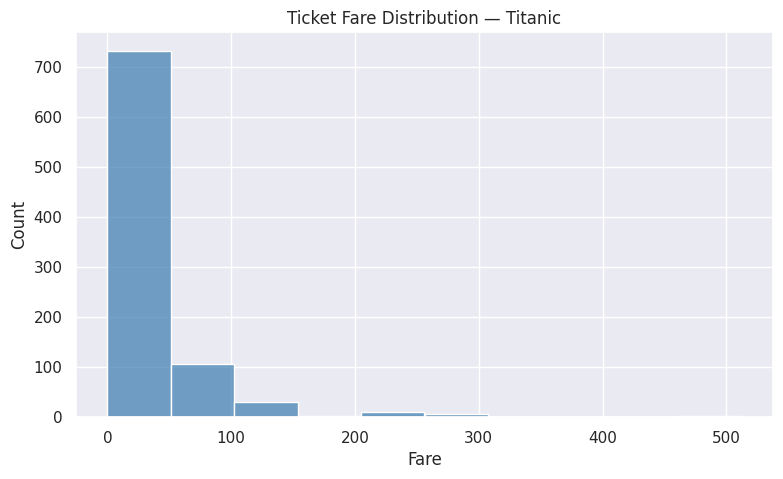

Observation:
  ~730 passengers paid fares in the 0–50 range.
  ~100 passengers paid fares around 50–100.
  Very few passengers paid above 300 (extreme outliers — luxury cabins).


In [37]:
# Basic histogram of fare
plt.figure(figsize=(9, 5))
sns.histplot(dataset['fare'], kde=False, bins=10, color='steelblue')
plt.title('Ticket Fare Distribution — Titanic')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

print("Observation:")
print("  ~730 passengers paid fares in the 0–50 range.")
print("  ~100 passengers paid fares around 50–100.")
print("  Very few passengers paid above 300 (extreme outliers — luxury cabins).")

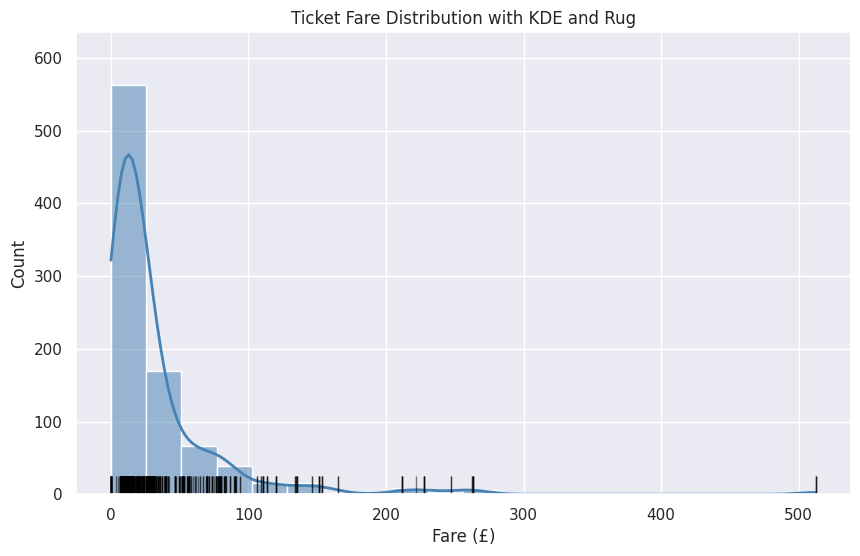

In [38]:
# Enhanced histogram with KDE and rug
plt.figure(figsize=(10, 6))
sns.histplot(dataset['fare'], kde=True, bins=20, color='steelblue', 
             line_kws={'color': 'red', 'lw': 2})
sns.rugplot(data=dataset, x='fare', color='black', height=0.04, alpha=0.5)
plt.title('Ticket Fare Distribution with KDE and Rug')
plt.xlabel('Fare (£)')
plt.ylabel('Count')
plt.show()

In [39]:
# Fare statistics
print("=== Fare Column Statistics ===")
print(dataset['fare'].describe())
print(f"\nSkewness : {dataset['fare'].skew():.4f}  (positive = right-skewed)")
print(f"Kurtosis : {dataset['fare'].kurtosis():.4f}")

=== Fare Column Statistics ===
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

Skewness : 4.7873  (positive = right-skewed)
Kurtosis : 33.3981


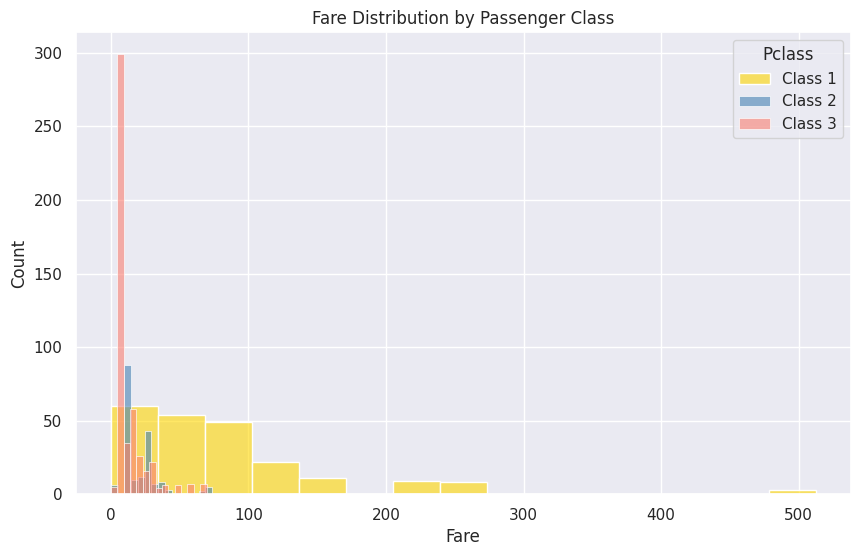

Observation: 3rd class passengers dominate the low-fare range.
1st class passengers paid a wide spread of fares, with some paying 500+.


In [40]:
# Fare histogram split by passenger class
plt.figure(figsize=(10, 6))
for pclass, color in zip([1, 2, 3], ['gold', 'steelblue', 'salmon']):
    subset = dataset[dataset['pclass'] == pclass]['fare']
    sns.histplot(subset, bins=15, kde=False, color=color, alpha=0.6, label=f'Class {pclass}')

plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.legend(title='Pclass')
plt.show()

print("Observation: 3rd class passengers dominate the low-fare range.")
print("1st class passengers paid a wide spread of fares, with some paying 500+.")

---
## Assignment Questions — Answers

**Q1. List out different types of plots to find patterns of data.**

| Category | Plot Types |
|---|---|
| Distribution | Dist Plot, Joint Plot, Rug Plot |
| Categorical | Bar Plot, Count Plot, Box Plot, Violin Plot |
| Advanced | Strip Plot, Swarm Plot |
| Matrix | Heat Map, Cluster Map |

---

**Q2. When to use distribution plots vs categorical plots?**

- **Distribution plots** are used when analyzing a **continuous/numeric** variable — to understand its spread, skewness, mean, variance (e.g., age, fare). They help identify outliers and underlying distribution shape.
- **Categorical plots** are used when comparing **groups or categories** (e.g., male vs female, class 1/2/3). They show aggregates (mean, count, std) or full distributions per category.

---

**Q3. Conclusion from the Swarm Plot (sex vs age, hue=survived):**

1. Male passengers have a significantly **lower survival ratio** — far more blue (non-surviving) points.
2. Female passengers have a **higher survival ratio** — more orange (surviving) points.
3. Among **male children under age 10**, survivors outnumber non-survivors.
4. Peak passenger density for both genders lies in the **20–40 age range**.

---

**Q4. `hue` parameter in Violin Plot — Syntax and Example:**

The `hue` parameter adds another categorical dimension to the plot by splitting/coloring the violin based on a second categorical column.

```python
# Syntax
sns.violinplot(x='categorical_col', y='numeric_col', data=df, hue='another_categorical_col')

# Example
sns.violinplot(x='sex', y='age', data=dataset, hue='survived', split=True)
```

Using `split=True` draws the two hue groups on opposite halves of the same violin for direct comparison.

---
## Conclusion

Seaborn is an advanced data visualization library built on top of Matplotlib. In this assignment:
- **Distribution plots** (distplot, jointplot, rugplot) helped analyze individual and bivariate distributions of numeric features like `age` and `fare`.
- **Categorical plots** (barplot, countplot, boxplot, violinplot) revealed group-level patterns such as gender-based age distributions and survival rates.
- **Advanced plots** (stripplot, swarmplot) gave point-level visibility for individual data samples.
- **Matrix plots** (heatmap, clustermap) exposed correlations between numeric features — notably that `fare` positively correlates with survival, while `pclass` negatively correlates with both fare and survival.
- The **fare histogram** confirmed strong right-skew: majority of passengers paid low fares (0–50), with a small number of high-fare outliers.